In [3]:
# --- CELL 1: SETUP & LOAD ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.preprocessing import MinMaxScaler

# 1. Load from the immutable "Raw" checkpoint
# (We do NOT query the database again. Fault tolerance!)
PARQUET_PATH = 'data/raw/raw_data.parquet'

if os.path.exists(PARQUET_PATH):
    df_raw = pd.read_parquet(PARQUET_PATH)
    print(f"✅ Loaded Checkpoint: {len(df_raw)} rows")
    display(df_raw.head())
else:
    print("❌ Error: 'raw_data.parquet' not found.")
    print("   -> Action: Go back to Notebook 01, Restart Kernel, and run the Save cell.")

✅ Loaded Checkpoint: 52018 rows


,time,flow_l_min,turbidity_ntu,tank_level,ph,pressure,anomaly_label
0,2025-07-20 10:46:54.440629+00:00,3.77,76.5,50.0,6.96,1.27,Normal
1,2025-07-20 10:51:54.440629+00:00,5.28,108.9,50.1,7.05,1.36,Normal
2,2025-07-20 10:56:54.440629+00:00,6.00,119.2,50.1,7.16,1.32,Normal
3,2025-07-20 11:01:54.440629+00:00,4.18,104.8,50.2,7.13,1.21,Normal
4,2025-07-20 11:06:54.440629+00:00,5.89,105.6,50.2,7.13,1.36,Normal


In [4]:
# --- CELL 2: FEATURE SELECTION ---

# We create a NEW variable (df_selected) instead of modifying df_raw
# We drop 'time' for the math (AI doesn't need dates), but keep 'anomaly_label' for targeting
features = ['flow_l_min', 'turbidity_ntu', 'tank_level', 'ph', 'pressure']
target_col = 'anomaly_label'

df_features = df_raw[features].copy()
labels = df_raw[target_col].values

print("✅ Features Selected:", features)

✅ Features Selected: ['flow_l_min', 'turbidity_ntu', 'tank_level', 'ph', 'pressure']


In [5]:
# --- CELL 3: NORMALIZATION (SCALING) ---

# Initialize the Scaler
scaler = MinMaxScaler()

# fit_transform returns a numpy array, losing column names
# We recreate the DataFrame immediately to keep it readable (Spark-style)
data_scaled_array = scaler.fit_transform(df_features)
df_scaled = pd.DataFrame(data_scaled_array, columns=features)

# Save the scaler tool (Artifact) so we can inverse this later
os.makedirs('data/artifacts', exist_ok=True)
joblib.dump(scaler, 'data/artifacts/scaler.gz')

print("✅ Data Normalized to [0, 1] range.")
print("   -> Flow Max before:", df_features['flow_l_min'].max())
print("   -> Flow Max after: ", df_scaled['flow_l_min'].max())
display(df_scaled.head())

✅ Data Normalized to [0, 1] range.
   -> Flow Max before: 17.99
   -> Flow Max after:  1.0


,flow_l_min,turbidity_ntu,tank_level,ph,pressure
0,0.209561,0.1060,0.0000,0.3650,0.262411
1,0.293496,0.2356,0.0025,0.3875,0.326241
2,0.333519,0.2768,0.0025,0.4150,0.297872
3,0.232351,0.2192,0.0050,0.4075,0.219858
4,0.327404,0.2224,0.0050,0.4075,0.326241


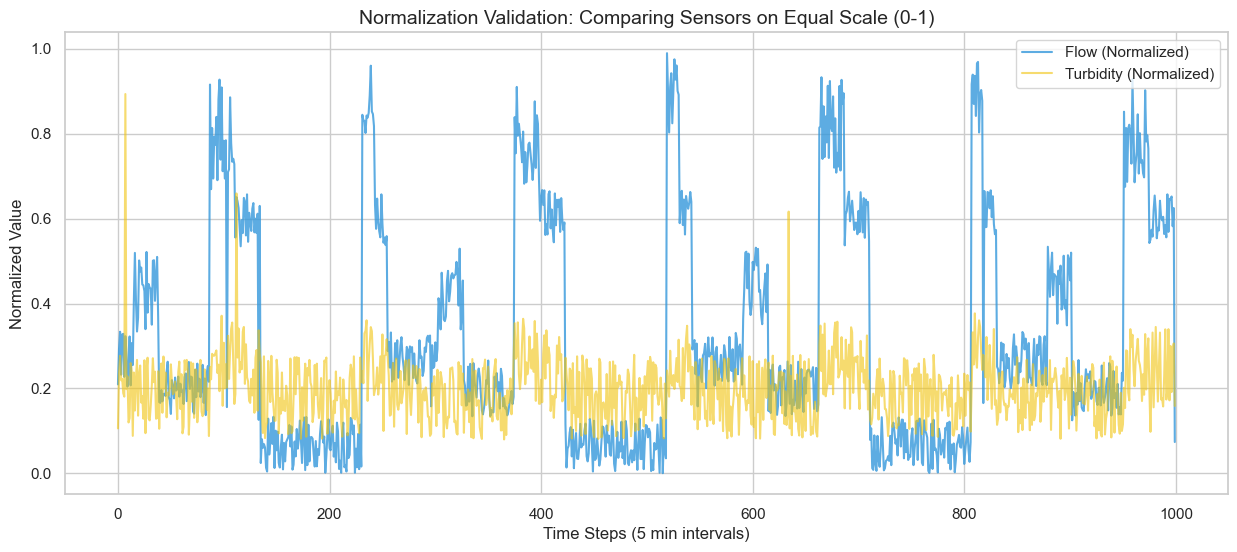

In [6]:
# --- CELL 4: VALIDATION PLOT ---
sns.set(style="whitegrid")
plt.figure(figsize=(15, 6))

# We take a slice of 1000 points (approx 3 days) to make it readable
slice_idx = 1000
subset = df_scaled.iloc[:slice_idx]

# Plot Flow vs Turbidity on the SAME axis
plt.plot(subset['flow_l_min'], label='Flow (Normalized)', color='#3498db', alpha=0.8)
plt.plot(subset['turbidity_ntu'], label='Turbidity (Normalized)', color='#f1c40f', alpha=0.6)

plt.title("Normalization Validation: Comparing Sensors on Equal Scale (0-1)", fontsize=14)
plt.xlabel("Time Steps (5 min intervals)")
plt.ylabel("Normalized Value")
plt.legend()
plt.show()

In [7]:
# --- CELL 5: SLIDING WINDOW (SEQUENCE GENERATION) ---

def create_sequences(data, labels, time_steps=12):
    X, y = [], []
    # We loop through the data, stopping before we run out of rows
    for i in range(len(data) - time_steps):
        # Input: The window of 'time_steps' (e.g., 12 steps = 60 mins)
        X.append(data[i:(i + time_steps)])
        
        # Output: The label at the END of the window
        # Convert 'Normal' -> 0, 'Leak'/'Chemical' -> 1
        label_str = labels[i + time_steps]
        label = 0 if label_str == 'Normal' else 1
        
        y.append(label)
    return np.array(X), np.array(y)

TIME_STEPS = 12 # 1 Hour context
X, y = create_sequences(df_scaled.values, labels, TIME_STEPS)

print(f"✅ Sequences Created.")
print(f"   X Shape: {X.shape} (Samples, TimeSteps, Features)")
print(f"   y Shape: {y.shape} (Samples, Label)")
print(f"   Total Anomaly Windows: {sum(y)}")

✅ Sequences Created.
   X Shape: (52006, 12, 5) (Samples, TimeSteps, Features)
   y Shape: (52006,) (Samples, Label)
   Total Anomaly Windows: 735


In [8]:
# --- CELL 6: SAVE PROCESSED DATA ---
os.makedirs('data/processed', exist_ok=True)

np.save('data/processed/X.npy', X)
np.save('data/processed/y.npy', y)

print("✅ SUCCESS: Processed training data saved to 'data/processed/'")
print("   -> Ready for Phase 3 (Notebook 03_Model_Training)")

✅ SUCCESS: Processed training data saved to 'data/processed/'
   -> Ready for Phase 3 (Notebook 03_Model_Training)
